# Wind Effects on Flight Planning

This notebook demonstrates how wind affects airborne remote sensing
missions — from crab angles and swath distortion to trochoidal Dubins
transit paths and total mission timing.

We examine the **same set of flight lines** under three wind conditions:
- **Headwind** — wind opposing the primary flight direction
- **Crosswind** — wind perpendicular to flight lines
- **Tailwind** — wind along the primary flight direction

For each, we show:
1. The complete mission plan (map + altitude profile)
2. Trochoidal Dubins transit arcs between flight lines
3. Crab angle and swath effects
4. Total mission timing comparison

For wind **data sources** (MERRA-2, GFS, GMAO), see `winds.ipynb`.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd

from hyplan import (
    FlightLine, DubinsPath3D,
    DynamicAviation_B200, AVIRIS3,
    Airport, initialize_data,
    compute_flight_plan, ConstantWindField, StillAirField,
    box_around_center_line,
    generate_swath_polygon, calculate_swath_widths,
    ureg,
)

## 1. Setup: Flight Lines, Aircraft, and Airport

We use east-west AVIRIS-3 flight lines at 20,000 ft over the Santa Barbara
Channel, departing from KSBA. The primary flight direction is ~90°/270°
(east-west), so:

- **Headwind** = wind from the east (90°), opposing eastbound legs
- **Crosswind** = wind from the south (180°), perpendicular to all legs
- **Tailwind** = wind from the west (270°), assisting eastbound legs

In [2]:
initialize_data(countries=["US"])

aircraft = DynamicAviation_B200()
sensor = AVIRIS3()
departure = Airport("KSBA")
flight_altitude = ureg.Quantity(20000, "feet")

# Generate east-west flight lines (alternating direction)
flight_lines = box_around_center_line(
    instrument=sensor,
    altitude_msl=flight_altitude,
    lat0=34.35, lon0=-119.7,
    azimuth=90.0,  # east-west
    box_length=ureg.Quantity(60, "km"),
    box_width=ureg.Quantity(15, "km"),
    box_name="SBC",
    overlap=20,
    alternate_direction=True,
)

cruise_speed = aircraft.cruise_speed_at(flight_altitude)
print(f"Aircraft: {aircraft.aircraft_type}")
print(f"Sensor:   {sensor.name}")
print(f"Altitude: {flight_altitude}")
print(f"Cruise:   {cruise_speed.to(ureg.knot):.0f}")
print(f"Airport:  {departure.name} ({departure.icao_code})")
print(f"Lines:    {len(flight_lines)} (alternating E/W)")
for fl in flight_lines:
    print(f"  {fl.site_name}: az={fl.az12:.0f}°, length={fl.length.to(ureg.km):.1f}")

Aircraft: King Air 200
Sensor:   AVIRIS 3
Altitude: 20000 foot
Cruise:   222 knot
Airport:  Santa Barbara Municipal Airport (KSBA)
Lines:    5 (alternating E/W)
  SBC_L01_FL200: az=270 degree°, length=60.0 kilometer
  SBC_L02_FL200: az=90 degree°, length=60.0 kilometer
  SBC_L03_FL200: az=270 degree°, length=60.0 kilometer
  SBC_L04_FL200: az=90 degree°, length=60.0 kilometer
  SBC_L05_FL200: az=270 degree°, length=60.0 kilometer


## 2. Compute Flight Plans Under Different Wind Conditions

We compute four flight plans: still air (baseline), plus headwind,
crosswind, and tailwind — all at 60 kt (a strong but realistic wind
for 20,000 ft).

In [3]:
wind_speed = 60 * ureg.knot

# Define wind conditions relative to the east-west flight lines
wind_cases = {
    "Still air": None,
    "Headwind (from E)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=90.0),
    "Crosswind (from S)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=180.0),
    "Crosswind (from N)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=0.0),
    "Crosswind (from SE)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=135.0),
    "Tailwind (from W)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=270.0),
}

plans = {}
for name, wf in wind_cases.items():
    plans[name] = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf if wf else StillAirField(),
    )

# Summary table
print(f"{'Condition':<22s}  {'Total (min)':>10s}  {'Data (min)':>10s}  {'Transit':>10s}  {'Δ vs still':>10s}")
print("-" * 68)
for name, plan in plans.items():
    total = plan["time_to_segment"].sum()
    data = plan[plan["segment_type"] == "flight_line"]["time_to_segment"].sum()
    transit = total - data
    delta = total - plans["Still air"]["time_to_segment"].sum()
    print(f"{name:<22s}  {total:10.1f}  {data:10.1f}  {transit:10.1f}  {delta:+10.1f}")

Condition               Total (min)  Data (min)     Transit  Δ vs still
--------------------------------------------------------------------
Still air                     83.9        51.9        32.0        +0.0
Headwind (from E)             87.4        52.9        34.5        +3.6
Crosswind (from S)            86.2        53.8        32.4        +2.3
Crosswind (from N)            86.8        53.9        32.8        +2.9
Crosswind (from SE)           86.1        52.7        33.3        +2.2
Tailwind (from W)             91.6        59.0        32.7        +7.8


## 3. Mission Plans — Map View

Each panel shows the complete mission (takeoff, transit, data collection,
return) plotted from the flight plan geometry. Compare how the Dubins
transit arcs change shape under different wind conditions — the circular
arcs in still air become trochoidal curves that drift with the wind.

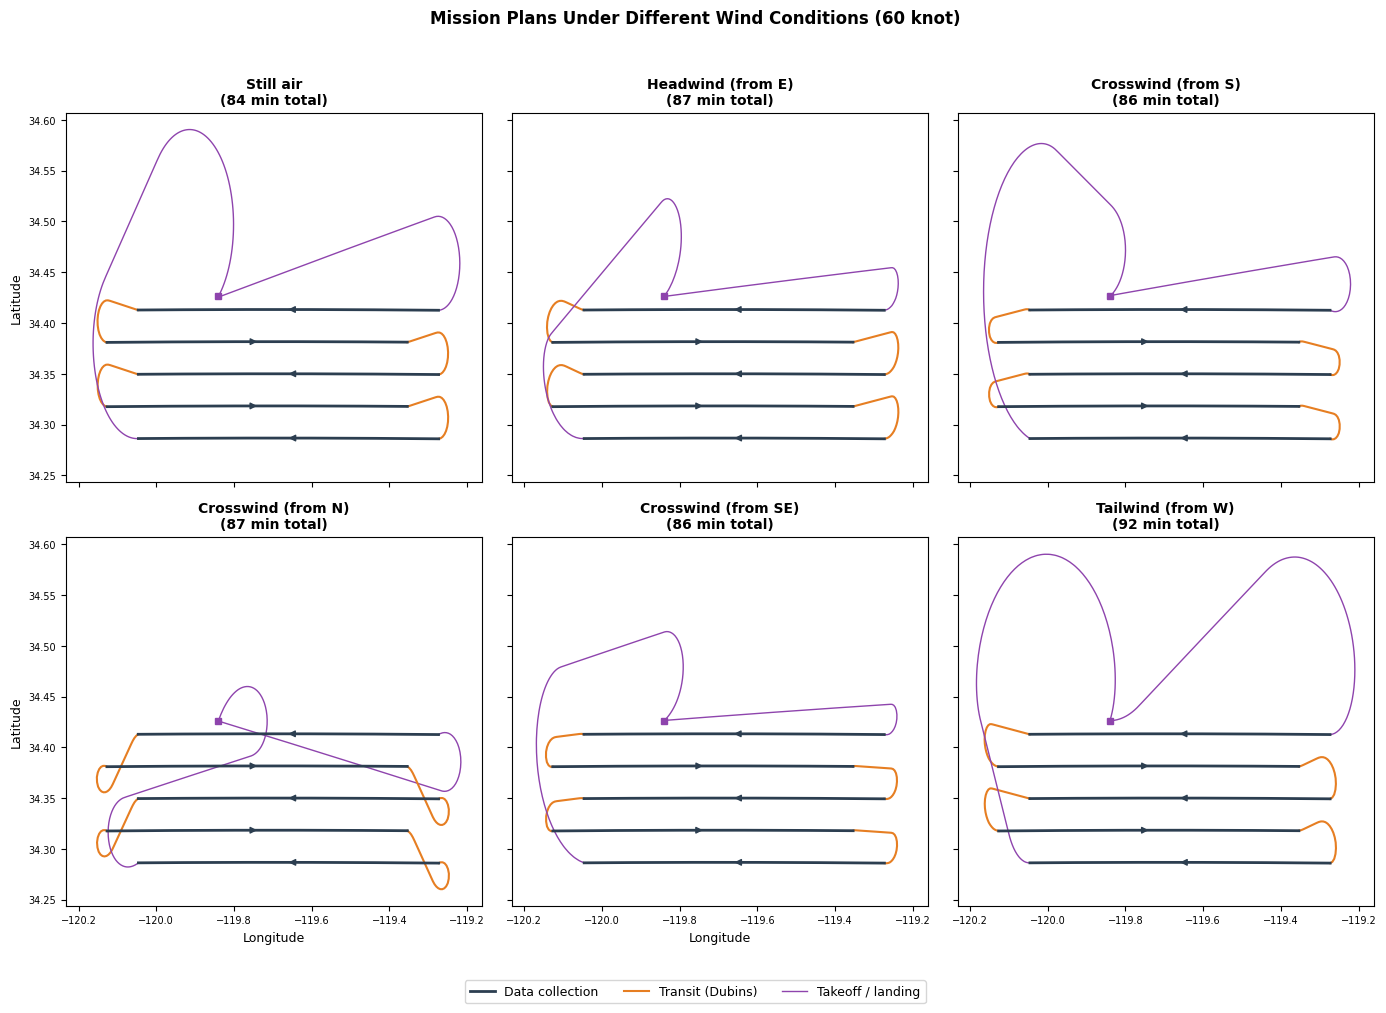

In [4]:
seg_colors = {
    "takeoff": "#8e44ad", "climb": "#8e44ad",
    "transit": "#e67e22",
    "flight_line": "#2c3e50",
    "descent": "#8e44ad", "approach": "#8e44ad",
}
seg_lw = {
    "takeoff": 1.0, "climb": 1.0,
    "transit": 1.5,
    "flight_line": 2.0,
    "descent": 1.0, "approach": 1.0,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=True, sharey=True)

for ax, (name, plan) in zip(axes.flat, plans.items()):
    # Plot each segment
    for _, seg in plan.iterrows():
        geom = seg.geometry
        if geom is None or geom.is_empty:
            continue
        seg_type = seg["segment_type"]
        color = seg_colors.get(seg_type, "#bdc3c7")
        lw = seg_lw.get(seg_type, 1.0)
        xs, ys = geom.xy
        ax.plot(xs, ys, color=color, linewidth=lw,
                zorder=3 if seg_type == "flight_line" else 2)

        # Direction arrows on flight lines
        if seg_type == "flight_line":
            mid = len(xs) // 2
            if mid > 0:
                ax.annotate("", xy=(xs[mid], ys[mid]),
                            xytext=(xs[mid - 1], ys[mid - 1]),
                            arrowprops=dict(arrowstyle="-|>", color=color, lw=1),
                            zorder=5)

    # Airport marker
    ax.plot(departure.longitude, departure.latitude, "s",
            color="#8e44ad", markersize=5, zorder=6)

    total_min = plan["time_to_segment"].sum()
    ax.set_title(f"{name}\n({total_min:.0f} min total)", fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=7)

axes[1, 0].set_xlabel("Longitude", fontsize=9)
axes[1, 1].set_xlabel("Longitude", fontsize=9)
axes[0, 0].set_ylabel("Latitude", fontsize=9)
axes[1, 0].set_ylabel("Latitude", fontsize=9)

# Shared legend
legend_elements = [
    plt.Line2D([0], [0], color="#2c3e50", lw=2, label="Data collection"),
    plt.Line2D([0], [0], color="#e67e22", lw=1.5, label="Transit (Dubins)"),
    plt.Line2D([0], [0], color="#8e44ad", lw=1, label="Takeoff / landing"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f"Mission Plans Under Different Wind Conditions ({wind_speed.to(ureg.knot):.0f})",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## 5. Crab Angles and Segment Timing

Wind creates a **crab angle** — the offset between the aircraft's heading
(nose direction) and the ground track (direction of motion). This table
shows crab angle, groundspeed, and timing for each flight line segment.

In [5]:
import pandas as pd

for name, plan in plans.items():
    fl_rows = plan[plan["segment_type"] == "flight_line"].copy()
    if fl_rows.empty or "crab_angle_deg" not in fl_rows.columns:
        continue

    print(f"\n{name}:")
    print(f"  {'Segment':<25s}  {'Track':>6s}  {'Heading':>7s}  {'Crab':>6s}  "
          f"{'GS (kt)':>7s}  {'Time':>6s}  {'Tail (kt)':>9s}  {'Xwind (kt)':>10s}")
    print("  " + "-" * 90)
    for _, row in fl_rows.iterrows():
        print(f"  {row['segment_name']:<25s}  "
              f"{row.get('planned_track', 0):6.0f}  "
              f"{row.get('wind_corrected_heading', 0):7.0f}  "
              f"{row.get('crab_angle_deg', 0):+6.1f}  "
              f"{row.get('groundspeed_kts', 0):7.0f}  "
              f"{row['time_to_segment']:6.1f}  "
              f"{row.get('tailwind_kts', 0):+9.0f}  "
              f"{row.get('crosswind_kts', 0):+10.0f}")


Still air:
  Segment                     Track  Heading    Crab  GS (kt)    Time  Tail (kt)  Xwind (kt)
  ------------------------------------------------------------------------------------------
  SBC_L01_FL200                 270      270    -0.0      222    10.4         +0          +0
  SBC_L02_FL200                  90       90    -0.0      222    10.4         +0          +0
  SBC_L03_FL200                 270      270    -0.0      222    10.4         +0          +0
  SBC_L04_FL200                  90       90    -0.0      222    10.4         +0          +0
  SBC_L05_FL200                 270      270    -0.0      222    10.4         +0          +0

Headwind (from E):
  Segment                     Track  Heading    Crab  GS (kt)    Time  Tail (kt)  Xwind (kt)
  ------------------------------------------------------------------------------------------
  SBC_L01_FL200                 270      270    +0.1      282     8.2        +60          -0
  SBC_L02_FL200                  90   

## 6. Wind Direction Sensitivity — Polar Plot

Sweep wind direction from 0° to 360° and plot total mission time
as a polar plot. This shows the full picture: which wind directions
are most costly and which are most favorable.

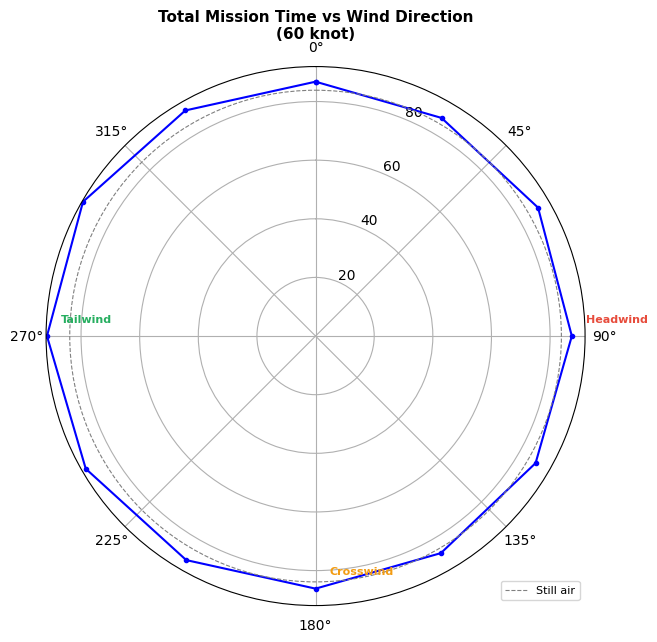


Still air: 84 min
Min time:  85 min (wind from 150°)
Max time:  92 min (wind from 270°)
Range:     6 min


In [6]:
directions = np.arange(0, 360, 30)
times = []

for d in directions:
    wf = ConstantWindField(wind_speed=wind_speed, wind_from_deg=float(d))
    plan = compute_flight_plan(
        aircraft=aircraft, flight_sequence=flight_lines,
        takeoff_airport=departure, return_airport=departure,
        wind_source=wf,
    )
    times.append(plan["time_to_segment"].sum())

still_time = plans["Still air"]["time_to_segment"].sum()

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
theta = np.radians(directions)
# Close the loop
theta_closed = np.append(theta, theta[0])
times_closed = np.append(times, times[0])

ax.plot(theta_closed, times_closed, "b-o", markersize=3, linewidth=1.5)
ax.axhline(still_time, color="gray", linestyle="--", linewidth=0.8, label="Still air")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title(f"Total Mission Time vs Wind Direction\n({wind_speed.to(ureg.knot):.0f})",
             fontsize=11, fontweight="bold", pad=20)

# Mark the three key directions
for angle, label, color in [(90, "Headwind", "#e74c3c"),
                             (180, "Crosswind", "#f39c12"),
                             (270, "Tailwind", "#27ae60")]:
    ax.annotate(label, xy=(np.radians(angle), times[directions.tolist().index(angle)]),
                fontsize=8, color=color, fontweight="bold",
                xytext=(10, 10), textcoords="offset points")

ax.legend(loc="lower right", fontsize=8)
plt.show()

print(f"\nStill air: {still_time:.0f} min")
print(f"Min time:  {min(times):.0f} min (wind from {directions[np.argmin(times)]}°)")
print(f"Max time:  {max(times):.0f} min (wind from {directions[np.argmax(times)]}°)")
print(f"Range:     {max(times) - min(times):.0f} min")

## Summary

| Wind condition | Effect on flight lines | Effect on transits | Effect on timing |
|---|---|---|---|
| **Headwind** | Groundspeed decreases, legs take longer | Trochoidal arcs drift downwind | Total time increases |
| **Crosswind** | Crab angle rotates sensor FOV relative to ground track | Arcs distorted perpendicular to flight direction | Moderate time increase from reduced ground speed |
| **Tailwind** | Groundspeed increases, legs are faster | Arcs drift downwind (same direction as flight) | Total time decreases |

Key takeaway: for east-west flight lines, **headwinds from along the line
direction** have the largest impact on total mission time, while
**crosswinds** primarily affect sensor geometry (crab angle and swath
rotation) rather than timing.